# INTERPOLATE ERA5, COMPUTE VSD

In [11]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature


import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

_______
# Data

In [12]:
#drifters_sources = 'all_med_variational_10min_v0.nc'
drifters_sources = '10days_all_med_variational_10min_v0.nc'
df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_59899/537765405.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))


In [4]:
files = glob('/Users/mdemol/DATA_WIND/era5/*')

In [5]:
files

['/Users/mdemol/DATA_WIND/era5/2023_waves_interp.nc',
 '/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1726002205.1540956-13738-7-c8d88fd1-3ec7-4113-8790-c92c59938aa6.nc',
 '/Users/mdemol/DATA_WIND/era5/2023_waves.nc',
 '/Users/mdemol/DATA_WIND/era5/corrected_coords_d68_interp.nc',
 '/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1726052574.6907787-10906-10-da2d6902-362a-4e2a-9333-df9d5a844d68.nc',
 '/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1725888040.2442634-4062-7-717f5d1f-4dbc-4297-ba65-42766024d861.nc']

# CORECT WRONG COORDS
era = xr.open_dataset('/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1726052574.6907787-10906-10-da2d6902-362a-4e2a-9333-df9d5a844d68.nc').sortby('latitude')
erac = xr.open_dataset('/Users/mdemol/DATA_WIND/era5/2023_waves.nc').sel(longitude050 = slice(0,15), latitude050 = slice(36, 45)).rename({'latitude050' :'latitude', 'longitude050' :'longitude'})
era['longitude'] = era['longitude']*2
era['latitude'] = (era['latitude']-40)*2+36
era = era.sel(longitude = slice(0,15), latitude = slice(36, 45))
erac = erac.sel(time = era.time)

era.to_netcdf('corrected_coords_d68.nc')
(era.mwd.isel(time=4)-erac.mwd.isel(time=4)).plot()

In [13]:
era5 = ['/Users/mdemol/DATA_WIND/era5/2023_waves_interp.nc',
        '/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1726002205.1540956-13738-7-c8d88fd1-3ec7-4113-8790-c92c59938aa6.nc',#u10 etc
        #'/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1725888040.2442634-4062-7-717f5d1f-4dbc-4297-ba65-42766024d861.nc' # lon, lat wrong coords
        #'/Users/mdemol/DATA_WIND/era5/corrected_coords_d68.nc',# corrected coords
        '/Users/mdemol/DATA_WIND/era5/corrected_coords_d68_interp.nc'#ust, vst etc
       ]
era = xr.open_mfdataset(era5)


In [7]:
era

<xarray.Dataset> Size: 2GB
Dimensions:    (longitude: 61, latitude: 33, time: 3672)
Coordinates:
  * longitude  (longitude) float32 244B 0.0 0.25 0.5 0.75 ... 14.5 14.75 15.0
  * latitude   (latitude) float32 132B 44.0 43.75 43.5 43.25 ... 36.5 36.25 36.0
  * time       (time) datetime64[ns] 29kB 2023-03-01 ... 2023-07-31T23:00:00
Data variables: (12/26)
    u10        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    v10        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    t2m        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    ewss       (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    iews       (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    inss       (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    ...         ...
    pp1d       (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    swh        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    shts       (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    ust        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    vst        (time, latitude, longitude) float64 59MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
    mwp        (time, latitude, longitude) float32 30MB dask.array<chunksize=(3672, 33, 61), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2024-09-10 21:05:21 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

__________
# era5 + RIO MODEL

In [14]:
def cst_rio_z0(df):
    
    theta0 = - 22.5 * np.pi / 180 * np.sign(df.f)
    beta0 = 0.6
    
    uek_e = beta0 * (np.cos(theta0) * df.taue - np.sin(theta0) * df.taun)
    uek_n = beta0 * (np.sin(theta0) * df.taue + np.cos(theta0) * df.taun)
    df['wde0_rio'] = df.f * uek_n
    df['wdn0_rio'] = -df.f * uek_e

def cst_rio_z15(df):
    
    theta15 = - 37.5 * np.pi / 180 * np.sign(df.f)#adapted for mediterranean sea
    beta15 = 0.15
    
    uek_e = beta15 * (np.cos(theta15) * df.taue - np.sin(theta15) * df.taun)
    uek_n = beta15 * (np.sin(theta15) * df.taue + np.cos(theta15) * df.taun)
    df['wde15_rio'] = df.f * uek_n
    df['wdn15_rio'] = -df.f * uek_e

def agescmed(df, z):
    # cstes
    rhow = 1.03*1e4
    rhoa = 1.2
    g = 9.81

    #vars
    U10 = df.u10 + 1j*df.v10
    u10 = np.conj(U10)*U10
    Us0 = df.ust + 1j *df.vst
    dxS = (df.lgws + 1j *df.mgws)/3600 #accumulated on one hour
    omega = 2*np.pi/df.mwp
    k = omega**2/g
    K = k*np.exp(1j*df.mwd*np.pi/180)
    
    Cd = (2.7/u10 + 0.142 +0.076*u10)/1e3 # neutral drag coeff
    Az = 1.2*1e-4 * U10**2 # vertical velocity profile considered uniform in the whole bassin m2.s-1
    #tau = rhoa * Cd * u10 * U10 # wind stress if not in the dataset
    tau = df.taue + 1j *df.taun
    m=(1+1j)*np.sqrt(df.f/(2*Az))
    
    Ue = tau/(rhow*Az*m)*np.exp(m*z)
    Utaus = dxS/(rhow*Az*m)*np.exp(m*z)
    if z==0: Us = Us0 #work well
    else : Us = m**2*Us0/(4*k**2-m**2)*np.exp(2*k*z)#PB
    Ues = -2*k*m*Us0/(4*k**2-m**2)*np.exp(m*z)

    U_ek = Ue + Utaus + Us + Ues
    df[f'uek{z}_agesc'] = np.real(U_ek)
    df[f'vek{z}_agesc'] = np.imag(U_ek)
    df[f'wde{z}_agesc'] = df.f * np.imag(U_ek)
    df[f'wdn{z}_agesc'] = -df.f * np.real(U_ek)

In [15]:
lon = df.longitude.values
lat = df.latitude.values
t = pd.to_datetime(df.datetime).values
ds0 = era.interp(longitude=('z', lon), latitude=('z',lat), time= ('z',t))
df0 = ds0.to_dataframe()
df0.index.names = ['row_number']
df0['f'] = 2 * 2 * np.pi / 86164.1 * np.sin(df0.latitude * np.pi / 180)
#df0 = df0.rename(columns = {'ewss':'taue', 'nsss':'taun'})
# Integrated stress -> mean stress
int_time = 1*3600
df0['taue'] = df0['iews']
df0['taun'] = df0['inss']
cst_rio_z0(df0)
cst_rio_z15(df0)
agescmed(df0, 0)
agescmed(df0, 15)
agescmed(df0, 50)
df0.to_csv(os.path.join(zarr_dir, 'era5_'+drifters_sources.replace('.nc', '')+'.csv'))

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: ylabel='Frequency'>

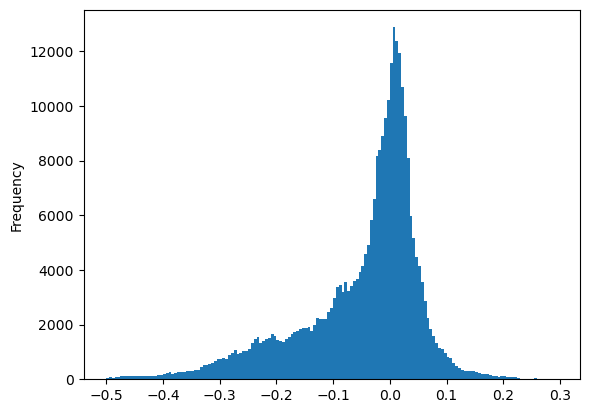

In [36]:
df0['vek0_agesc'].plot.hist(bins=np.arange(-0.50, 0.30, 5e-3))

<Axes: ylabel='Frequency'>

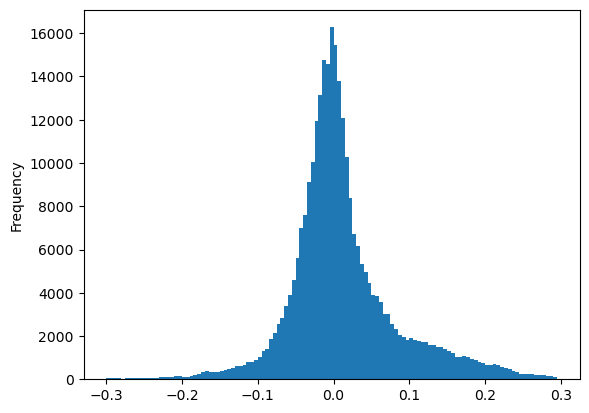

In [34]:
df0['uek0_agesc'].plot.hist(bins=np.arange(-0.30, 0.30, 5e-3))

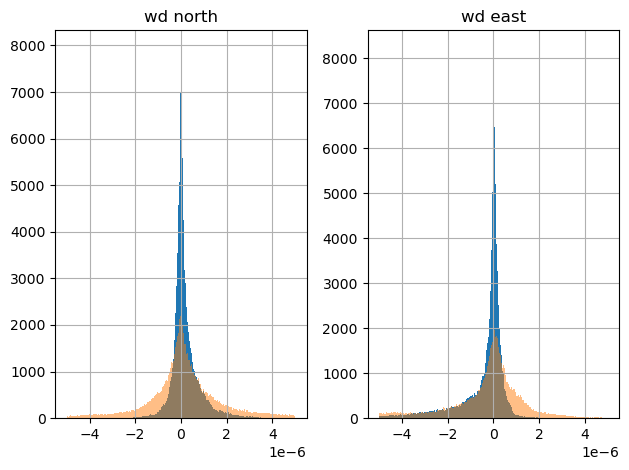

In [229]:
fig, axs = plt.subplots(1,2)
ax=axs[0]
bins = np.arange(-5e-6, 5e-6, 1e-8)
df0.wdn15.hist(bins =bins, ax=ax, label = '15m')
df0.wdn0.hist(bins =bins, ax=ax, alpha=0.5, label='surface')
ax.set_title('wd north')
ax=axs[1]
df0.wde15.hist(bins =bins, ax=ax, label = '15m')
df0.wde0.hist(bins =bins, ax=ax, alpha=0.5, label='surface')
ax.set_title('wd east')
fig.tight_layout()

In [13]:
#df0.to_csv(os.path.join(zarr_dir, 'era5_'+drifters_sources.replace('.nc', '')+'.csv'))

In [18]:
df0.wdn15.mean(), df0.wdn15.std()

(1.7849408319287998e-07, 6.490975129960646e-07)

In [19]:
abs(df0.wdn15).median()

1.959757111892836e-07

In [20]:
abs(df0.wde15).median()

2.2934632107256488e-07